# 🔵 K-Nearest Neighbours (KNN) — In-Depth Intuition
### Classification & Regression

---

## 📚 Table of Contents
1. What is KNN?
2. How KNN Works — Intuition
3. Distance Metrics (Euclidean, Manhattan, Minkowski)
4. Choosing the right K
5. KNN for Classification (from scratch + sklearn)
6. KNN for Regression
7. Pros & Cons of KNN
8. Hands-On: Iris Dataset (Classification)
9. Hands-On: Boston Housing (Regression)
10. Visualizations


---
## 1️⃣ What is KNN?

**K-Nearest Neighbours (KNN)** is a simple, powerful, and non-parametric supervised machine learning algorithm.

- **Non-parametric**: No assumptions about data distribution.
- **Lazy Learner**: It does NOT learn a model during training. It memorizes the entire dataset and makes predictions at query time.
- **Instance-based**: Predictions are based on the training instances closest to the query point.

### 💡 Core Idea:
> *"Tell me who your neighbours are, and I'll tell you who you are."*

KNN classifies a new data point based on the **majority class** of its K nearest neighbours (for classification) or the **average** of their values (for regression).

---
## 2️⃣ How KNN Works — Intuition

### 📌 Step-by-step Algorithm:

```
1. Choose the number K (number of neighbours)
2. Calculate the distance between the query point and ALL training points
3. Sort the distances and pick the K closest points
4. For Classification → Majority vote among K neighbours
   For Regression    → Mean/Average of K neighbours' values
5. Assign the result as the prediction
```

### 🖼️ Visual Example:
```
      🔴 🔴
   🔴    ❓    🔵
      🔴    🔵
          🔵 🔵

For K=3: The 3 nearest points to ❓ are [🔴, 🔴, 🔴]
→ ❓ is classified as 🔴

For K=5: The 5 nearest points = [🔴, 🔴, 🔴, 🔵, 🔵]
→ Still 🔴 (majority = 3 vs 2)
```

---
## 3️⃣ Distance Metrics

KNN relies on **distance** to find neighbours. Common metrics:

| Metric | Formula | When to Use |
|---|---|---|
| **Euclidean** | √(Σ(xᵢ - yᵢ)²) | Default; continuous features |
| **Manhattan** | Σ\|xᵢ - yᵢ\| | When outliers present; grid-like data |
| **Minkowski** | (Σ\|xᵢ - yᵢ\|ᵖ)^(1/p) | Generalization of both (p=2→Euclidean, p=1→Manhattan) |
| **Hamming** | Count of mismatches / n | Categorical data |

### ⚠️ Important: Feature Scaling is MANDATORY for KNN!
- KNN is distance-based, so features with large scales will dominate.
- Always apply **StandardScaler** or **MinMaxScaler** before KNN.

In [2]:
# ============================================================
# 📦 Install required libraries (run once if needed)
# ============================================================
!pip install numpy pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ============================================================
# 📦 Import Libraries
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

from sklearn.datasets import load_iris, load_diabetes, make_classification, make_regression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 4️⃣ Distance Metrics — Python Implementation

In [4]:
# ============================================================
# 📐 Distance Metric Implementations
# ============================================================

def euclidean_distance(p1, p2):
    """Standard straight-line distance."""
    return np.sqrt(np.sum((np.array(p1) - np.array(p2))**2))

def manhattan_distance(p1, p2):
    """Sum of absolute differences (taxi-cab distance)."""
    return np.sum(np.abs(np.array(p1) - np.array(p2)))

def minkowski_distance(p1, p2, p=2):
    """Generalized distance: p=1→Manhattan, p=2→Euclidean."""
    return np.sum(np.abs(np.array(p1) - np.array(p2))**p)**(1/p)

# Example
point_A = [2, 3]
point_B = [5, 7]

print(f"Points: A={point_A}, B={point_B}")
print(f"\n🔵 Euclidean Distance  : {euclidean_distance(point_A, point_B):.4f}")
print(f"🔴 Manhattan Distance  : {manhattan_distance(point_A, point_B):.4f}")
print(f"🟢 Minkowski (p=3)     : {minkowski_distance(point_A, point_B, p=3):.4f}")

Points: A=[2, 3], B=[5, 7]

🔵 Euclidean Distance  : 5.0000
🔴 Manhattan Distance  : 7.0000
🟢 Minkowski (p=3)     : 4.4979


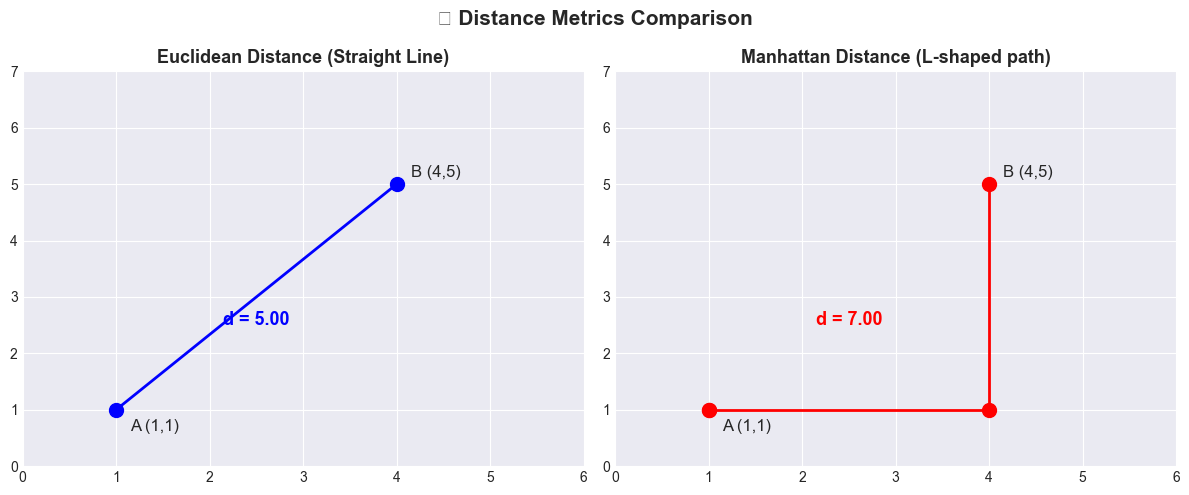

In [5]:
# ============================================================
# 📊 Visualize Distance Metrics
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

A = np.array([1, 1])
B = np.array([4, 5])

# Euclidean
ax = axes[0]
ax.plot([A[0], B[0]], [A[1], B[1]], 'b-o', linewidth=2, markersize=10)
ax.annotate('A (1,1)', A, textcoords='offset points', xytext=(10,-15), fontsize=12)
ax.annotate('B (4,5)', B, textcoords='offset points', xytext=(10,5), fontsize=12)
ax.text(2.5, 2.5, f"d = {euclidean_distance(A,B):.2f}", fontsize=13,
        color='blue', ha='center', fontweight='bold')
ax.set_title('Euclidean Distance (Straight Line)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 6); ax.set_ylim(0, 7)
ax.grid(True)

# Manhattan
ax = axes[1]
ax.plot([A[0], B[0], B[0]], [A[1], A[1], B[1]], 'r-o', linewidth=2, markersize=10)
ax.plot([A[0]], [A[1]], 'ro', markersize=10)
ax.annotate('A (1,1)', A, textcoords='offset points', xytext=(10,-15), fontsize=12)
ax.annotate('B (4,5)', B, textcoords='offset points', xytext=(10,5), fontsize=12)
ax.text(2.5, 2.5, f"d = {manhattan_distance(A,B):.2f}", fontsize=13,
        color='red', ha='center', fontweight='bold')
ax.set_title('Manhattan Distance (L-shaped path)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 6); ax.set_ylim(0, 7)
ax.grid(True)

plt.suptitle('🔢 Distance Metrics Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5️⃣ KNN from Scratch — Classification

In [6]:
# ============================================================
# 🧱 KNN Classifier — Built from Scratch
# ============================================================

class KNNClassifierScratch:
    """K-Nearest Neighbours Classifier implemented from scratch."""
    
    def __init__(self, k=3, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric
    
    def fit(self, X_train, y_train):
        """KNN doesn't actually learn — it just memorizes training data."""
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)
        print(f"✅ Model 'trained' (memorized {len(X_train)} samples)")
    
    def _compute_distance(self, p1, p2):
        if self.distance_metric == 'euclidean':
            return euclidean_distance(p1, p2)
        elif self.distance_metric == 'manhattan':
            return manhattan_distance(p1, p2)
    
    def predict_single(self, x):
        """Predict class for a single data point."""
        # Step 1: Compute distance to all training points
        distances = [self._compute_distance(x, x_train) for x_train in self.X_train]
        
        # Step 2: Get indices of K nearest neighbours
        k_indices = np.argsort(distances)[:self.k]
        
        # Step 3: Get labels of K nearest neighbours
        k_labels = [self.y_train[i] for i in k_indices]
        
        # Step 4: Majority vote
        most_common = Counter(k_labels).most_common(1)[0][0]
        return most_common
    
    def predict(self, X):
        """Predict classes for multiple data points."""
        return np.array([self.predict_single(x) for x in X])
    
    def score(self, X, y):
        predictions = self.predict(X)
        return np.sum(predictions == y) / len(y)

print("✅ KNNClassifierScratch class defined!")

✅ KNNClassifierScratch class defined!


In [7]:
# ============================================================
# 🧪 Test KNN Scratch on a Simple Dataset
# ============================================================

# Simple 2D dataset
X_simple = np.array([
    [1, 2], [1.5, 1.8], [5, 8], [8, 8],
    [1, 0.6], [9, 11], [8, 2], [10, 2],
    [9, 3], [2, 3], [3, 2], [7, 9]
])
y_simple = np.array([0, 0, 1, 1, 0, 1, 2, 2, 2, 0, 0, 1])

# Split
X_tr, X_te, y_tr, y_te = train_test_split(X_simple, y_simple, test_size=0.3, random_state=42)

# Train and test our scratch KNN
knn_scratch = KNNClassifierScratch(k=3)
knn_scratch.fit(X_tr, y_tr)

accuracy = knn_scratch.score(X_te, y_te)
print(f"\n🎯 Accuracy (Scratch KNN, K=3): {accuracy * 100:.2f}%")

# Test on a new point
new_point = [3, 4]
pred = knn_scratch.predict_single(new_point)
class_names = {0: 'Class A', 1: 'Class B', 2: 'Class C'}
print(f"\n🔮 Prediction for point {new_point}: {class_names[pred]}")

✅ Model 'trained' (memorized 8 samples)

🎯 Accuracy (Scratch KNN, K=3): 100.00%

🔮 Prediction for point [3, 4]: Class A


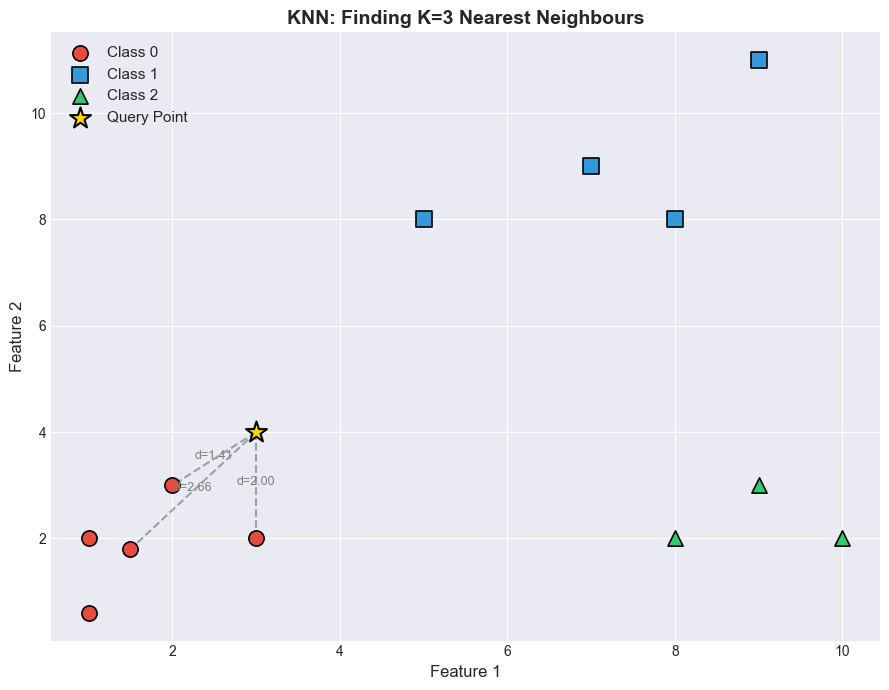

In [8]:
# ============================================================
# 📊 Visualize KNN Decision — Simple Dataset
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

colors = ['#E74C3C', '#3498DB', '#2ECC71']
markers = ['o', 's', '^']
for cls in range(3):
    mask = y_simple == cls
    ax.scatter(X_simple[mask, 0], X_simple[mask, 1],
               c=colors[cls], marker=markers[cls],
               s=120, label=f'Class {cls}', edgecolors='black', linewidth=1.2, zorder=3)

# Show the query point and its neighbours
query = np.array([3, 4])
ax.scatter(*query, c='gold', s=250, marker='*', zorder=5, label='Query Point', edgecolors='black', linewidth=1.5)

# Draw lines to K=3 nearest neighbours
distances = [(euclidean_distance(query, x), i) for i, x in enumerate(X_simple)]
distances.sort()
for dist, i in distances[:3]:
    ax.plot([query[0], X_simple[i, 0]], [query[1], X_simple[i, 1]],
            'gray', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.annotate(f'd={dist:.2f}', xy=((query[0]+X_simple[i,0])/2, (query[1]+X_simple[i,1])/2),
                fontsize=9, color='gray', ha='center')

ax.set_title('KNN: Finding K=3 Nearest Neighbours', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## 6️⃣ Choosing the Right K

**K** is the most critical hyperparameter in KNN:

| K Value | Effect | Risk |
|---|---|---|
| K = 1 | Very flexible, follows training data exactly | **Overfitting** — High Variance |
| K = large | Smoother decision boundary | **Underfitting** — High Bias |
| K = optimal | Balance between bias and variance | Best generalization |

### 🔑 Rule of Thumb:
- Start with `K = √N` where N = number of training samples
- Always choose **odd K** for binary classification (avoids ties)
- Use **Cross-Validation** to find the best K

✅ Best K = 6 with CV Accuracy = 96.67%


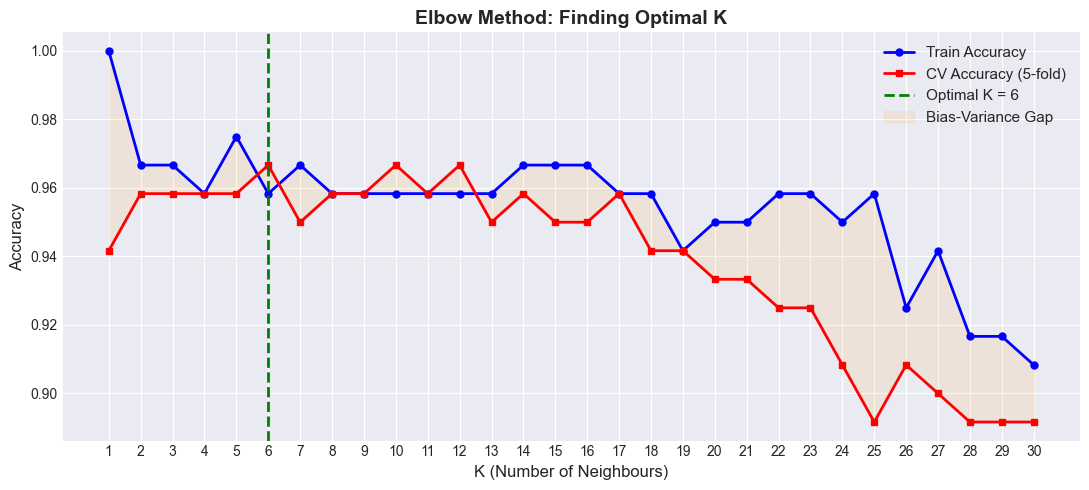

In [10]:
# ============================================================
# 🔍 Finding Optimal K using Cross-Validation (Elbow Method)
# ============================================================

# Load Iris Dataset
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# Scale features
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# Test K from 1 to 30
k_values = range(1, 31)
cv_scores = []
train_scores = []

X_tr_iris, X_te_iris, y_tr_iris, y_te_iris = train_test_split(
    X_iris_scaled, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # 5-fold cross validation
    scores = cross_val_score(knn, X_tr_iris, y_tr_iris, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    # Train accuracy
    knn.fit(X_tr_iris, y_tr_iris)
    train_scores.append(knn.score(X_tr_iris, y_tr_iris))

optimal_k = k_values[np.argmax(cv_scores)]
print(f"✅ Best K = {optimal_k} with CV Accuracy = {max(cv_scores)*100:.2f}%")

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(k_values, train_scores, 'b-o', markersize=5, label='Train Accuracy', linewidth=2)
ax.plot(k_values, cv_scores, 'r-s', markersize=5, label='CV Accuracy (5-fold)', linewidth=2)
ax.axvline(x=optimal_k, color='green', linestyle='--', linewidth=2, label=f'Optimal K = {optimal_k}')
ax.fill_between(k_values, train_scores, cv_scores, alpha=0.1, color='orange', label='Bias-Variance Gap')
ax.set_xlabel('K (Number of Neighbours)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Elbow Method: Finding Optimal K', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

---
## 7️⃣ KNN for Classification — Iris Dataset (with sklearn)

In [11]:
# ============================================================
# 🌸 KNN Classification — Iris Dataset (Full Pipeline)
# ============================================================

print("📊 Dataset Overview:")
print(f"   Features: {iris.feature_names}")
print(f"   Target Classes: {iris.target_names}")
print(f"   Shape: {X_iris.shape}")

iris_df = pd.DataFrame(X_iris, columns=iris.feature_names)
iris_df['species'] = [iris.target_names[i] for i in y_iris]
print(f"\n{iris_df.head(5)}")
print(f"\n{iris_df.describe().round(2)}")

📊 Dataset Overview:
   Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
   Target Classes: ['setosa' 'versicolor' 'virginica']
   Shape: (150, 4)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
std                 0.83              0.44               1.77   
m

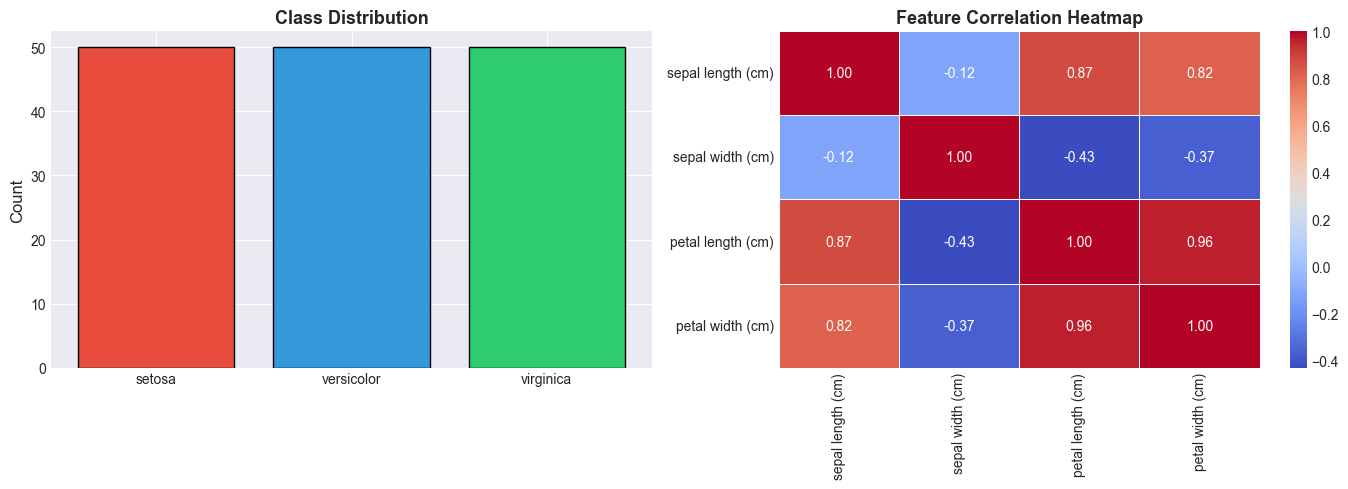

In [12]:
# ============================================================
# 🔄 Step 1: Exploratory Data Analysis (EDA)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pairplot using seaborn
# Count plot
axes[0].bar(iris.target_names,
            [sum(y_iris == i) for i in range(3)],
            color=['#E74C3C', '#3498DB', '#2ECC71'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)

# Feature correlation
corr = iris_df.drop('species', axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], linewidths=0.5)
axes[1].set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# 🔄 Step 2: Train KNN Classifier (sklearn) with optimal K
# ============================================================

# Use optimal K found earlier
knn_clf = KNeighborsClassifier(
    n_neighbors=optimal_k,
    metric='euclidean',
    weights='uniform'      # 'uniform' = all neighbours equal, 'distance' = closer neighbours weigh more
)
knn_clf.fit(X_tr_iris, y_tr_iris)

y_pred_iris = knn_clf.predict(X_te_iris)

print(f"\n{'='*50}")
print(f"  KNN Classification Report (K={optimal_k})")
print(f"{'='*50}")
print(f"  Accuracy: {accuracy_score(y_te_iris, y_pred_iris)*100:.2f}%\n")
print(classification_report(y_te_iris, y_pred_iris, target_names=iris.target_names))


  KNN Classification Report (K=6)
  Accuracy: 93.33%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



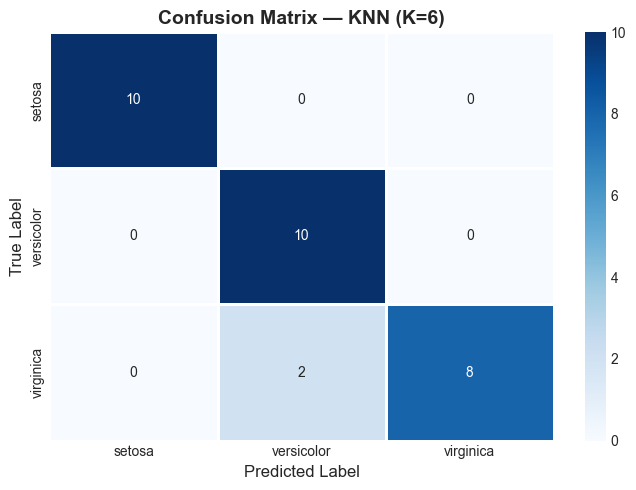

In [14]:
# ============================================================
# 📊 Confusion Matrix Visualization
# ============================================================

cm = confusion_matrix(y_te_iris, y_pred_iris)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names,
            linewidths=1, linecolor='white', ax=ax)
ax.set_title(f'Confusion Matrix — KNN (K={optimal_k})', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

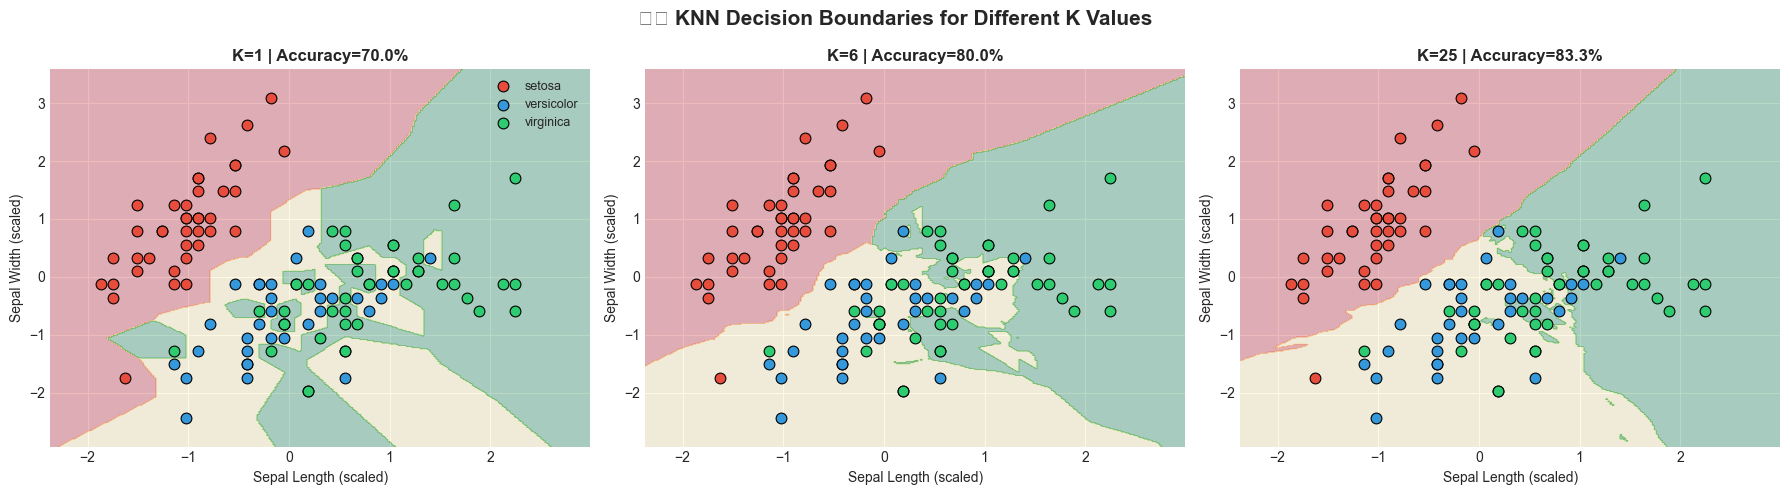

📌 Notice: K=1 → very jagged (overfitting), K=25 → overly smooth (underfitting)


In [15]:
# ============================================================
# 🗺️ Decision Boundary Visualization (2D — using 2 features)
# ============================================================

# Use only 2 features for visualization
X_2d = X_iris_scaled[:, :2]   # sepal length & width
X_tr_2d, X_te_2d, y_tr_2d, y_te_2d = train_test_split(X_2d, y_iris, test_size=0.2, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
k_list = [1, optimal_k, 25]

for ax, k in zip(axes, k_list):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_tr_2d, y_tr_2d)
    
    h = 0.02
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
    
    colors = ['#E74C3C', '#3498DB', '#2ECC71']
    for cls in range(3):
        mask = y_tr_2d == cls
        ax.scatter(X_tr_2d[mask, 0], X_tr_2d[mask, 1],
                   c=colors[cls], s=60, edgecolors='black', linewidth=0.8, label=iris.target_names[cls])
    
    score = clf.score(X_te_2d, y_te_2d)
    ax.set_title(f'K={k} | Accuracy={score*100:.1f}%', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sepal Length (scaled)', fontsize=10)
    ax.set_ylabel('Sepal Width (scaled)', fontsize=10)
    if k == k_list[0]:
        ax.legend(fontsize=9)

plt.suptitle('🗺️ KNN Decision Boundaries for Different K Values', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("📌 Notice: K=1 → very jagged (overfitting), K=25 → overly smooth (underfitting)")

---
## 8️⃣ KNN for Regression

Instead of majority vote, KNN Regression takes the **average** of K nearest neighbours' target values.

$$\hat{y} = \frac{1}{K} \sum_{i \in N_K(x)} y_i$$

Or with **distance weighting**:

$$\hat{y} = \frac{\sum_{i \in N_K(x)} \frac{y_i}{d_i}}{\sum_{i \in N_K(x)} \frac{1}{d_i}}$$

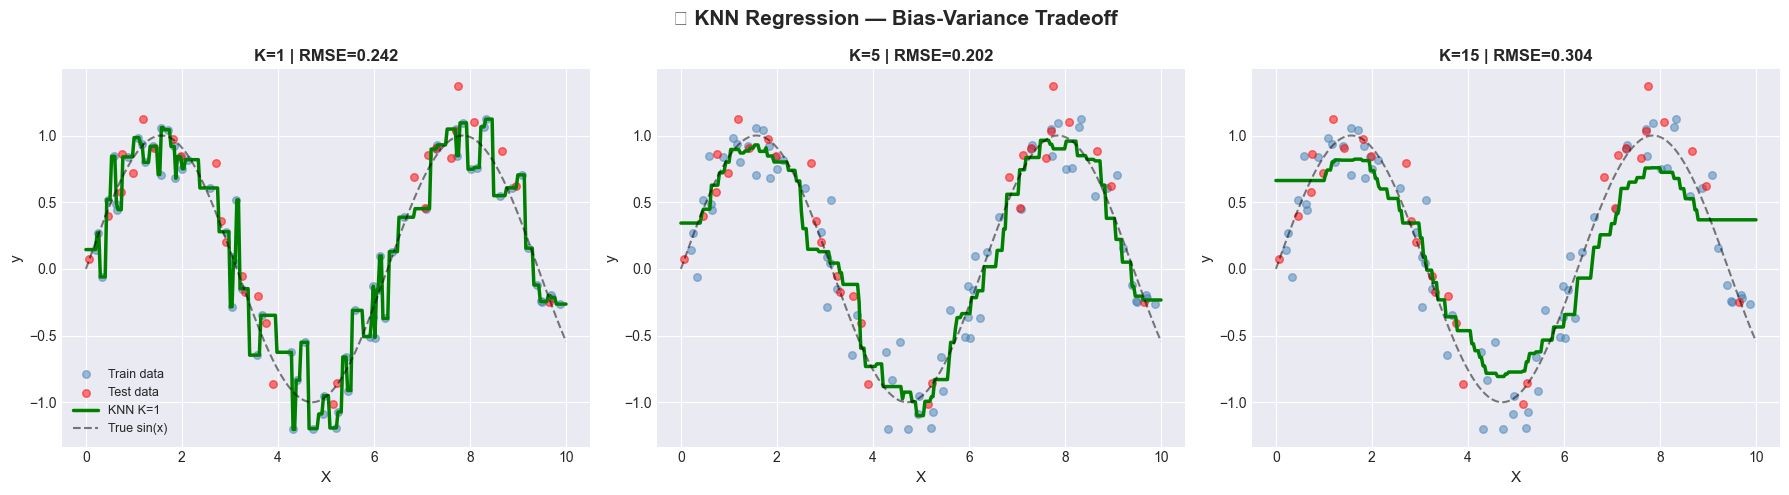

In [16]:
# ============================================================
# 🧱 KNN Regressor — From Scratch
# ============================================================

class KNNRegressorScratch:
    """K-Nearest Neighbours Regressor implemented from scratch."""
    
    def __init__(self, k=3, weights='uniform'):
        self.k = k
        self.weights = weights  # 'uniform' or 'distance'
    
    def fit(self, X_train, y_train):
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)
    
    def predict_single(self, x):
        distances = [euclidean_distance(x, x_tr) for x_tr in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_labels = self.y_train[k_indices]
        k_dists = np.array(distances)[k_indices]
        
        if self.weights == 'uniform':
            return np.mean(k_labels)
        elif self.weights == 'distance':
            # Avoid division by zero
            k_dists = np.where(k_dists == 0, 1e-10, k_dists)
            weights = 1 / k_dists
            return np.sum(weights * k_labels) / np.sum(weights)
    
    def predict(self, X):
        return np.array([self.predict_single(x) for x in X])

# Demo on sine wave
np.random.seed(42)
X_reg = np.sort(np.random.uniform(0, 10, 100)).reshape(-1, 1)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.2, 100)

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# Predict with different K values
X_plot = np.linspace(0, 10, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
k_vals = [1, 5, 15]

for ax, k in zip(axes, k_vals):
    reg = KNNRegressorScratch(k=k)
    reg.fit(X_tr_r, y_tr_r)
    y_pred_plot = reg.predict(X_plot)
    y_pred_test = reg.predict(X_te_r)
    
    rmse = np.sqrt(mean_squared_error(y_te_r, y_pred_test))
    
    ax.scatter(X_tr_r, y_tr_r, c='steelblue', alpha=0.5, s=30, label='Train data')
    ax.scatter(X_te_r, y_te_r, c='red', alpha=0.5, s=30, label='Test data')
    ax.plot(X_plot, y_pred_plot, 'g-', linewidth=2.5, label=f'KNN K={k}')
    ax.plot(X_plot, np.sin(X_plot), 'k--', alpha=0.5, linewidth=1.5, label='True sin(x)')
    ax.set_title(f'K={k} | RMSE={rmse:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('X', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    if k == 1:
        ax.legend(fontsize=9)

plt.suptitle('📈 KNN Regression — Bias-Variance Tradeoff', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# 📊 KNN Regression — sklearn on Diabetes Dataset
# ============================================================

diabetes = load_diabetes()
X_diab, y_diab = diabetes.data, diabetes.target

print(f"Dataset: {X_diab.shape[0]} samples, {X_diab.shape[1]} features")
print(f"Target (disease progression): min={y_diab.min():.0f}, max={y_diab.max():.0f}")

# Split & Scale
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(X_diab, y_diab, test_size=0.2, random_state=42)
scaler_d = StandardScaler()
X_tr_d_sc = scaler_d.fit_transform(X_tr_d)
X_te_d_sc = scaler_d.transform(X_te_d)

# Find optimal K for regression using RMSE
k_values = range(1, 31)
rmse_scores = []
for k in k_values:
    knn_r = KNeighborsRegressor(n_neighbors=k, weights='distance')
    cv_rmse = np.sqrt(-cross_val_score(knn_r, X_tr_d_sc, y_tr_d,
                                        cv=5, scoring='neg_mean_squared_error'))
    rmse_scores.append(cv_rmse.mean())

best_k_reg = list(k_values)[np.argmin(rmse_scores)]
print(f"\n✅ Best K for Regression = {best_k_reg} | CV RMSE = {min(rmse_scores):.2f}")

# Train final model
knn_reg = KNeighborsRegressor(n_neighbors=best_k_reg, weights='distance', metric='euclidean')
knn_reg.fit(X_tr_d_sc, y_tr_d)
y_pred_d = knn_reg.predict(X_te_d_sc)

print(f"\n📊 Final Model Results:")
print(f"   MAE  : {mean_absolute_error(y_te_d, y_pred_d):.2f}")
print(f"   RMSE : {np.sqrt(mean_squared_error(y_te_d, y_pred_d)):.2f}")
print(f"   R²   : {r2_score(y_te_d, y_pred_d):.4f}")

Dataset: 442 samples, 10 features
Target (disease progression): min=25, max=346

✅ Best K for Regression = 18 | CV RMSE = 58.54

📊 Final Model Results:
   MAE  : 44.99
   RMSE : 54.76
   R²   : 0.4341


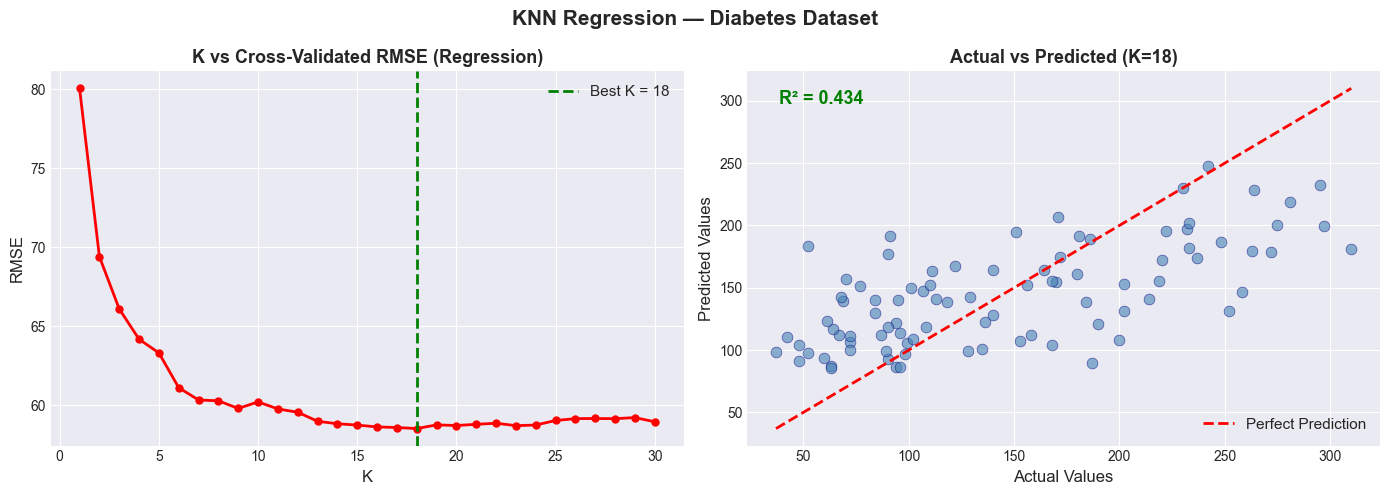

In [18]:
# ============================================================
# 📊 Regression Visualization: Actual vs Predicted
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K vs RMSE
ax = axes[0]
ax.plot(k_values, rmse_scores, 'r-o', linewidth=2, markersize=5)
ax.axvline(x=best_k_reg, color='green', linestyle='--', linewidth=2, label=f'Best K = {best_k_reg}')
ax.set_title('K vs Cross-Validated RMSE (Regression)', fontsize=13, fontweight='bold')
ax.set_xlabel('K', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.legend(fontsize=11)

# Actual vs Predicted
ax = axes[1]
ax.scatter(y_te_d, y_pred_d, alpha=0.6, color='steelblue', edgecolors='navy', linewidth=0.5, s=60)
min_val, max_val = min(y_te_d.min(), y_pred_d.min()), max(y_te_d.max(), y_pred_d.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_title(f'Actual vs Predicted (K={best_k_reg})', fontsize=13, fontweight='bold')
ax.set_xlabel('Actual Values', fontsize=12)
ax.set_ylabel('Predicted Values', fontsize=12)
ax.legend(fontsize=11)
ax.text(0.05, 0.95, f'R² = {r2_score(y_te_d, y_pred_d):.3f}',
        transform=ax.transAxes, fontsize=13, color='green', fontweight='bold', va='top')

plt.suptitle('KNN Regression — Diabetes Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9️⃣ Weighted KNN

Instead of equal votes, give **closer neighbours more weight**:

- `weights='uniform'` → All K neighbours have equal say
- `weights='distance'` → Closer neighbours have **more influence**

Weighted KNN often performs better, especially when there are **noisy data points** far from the query.

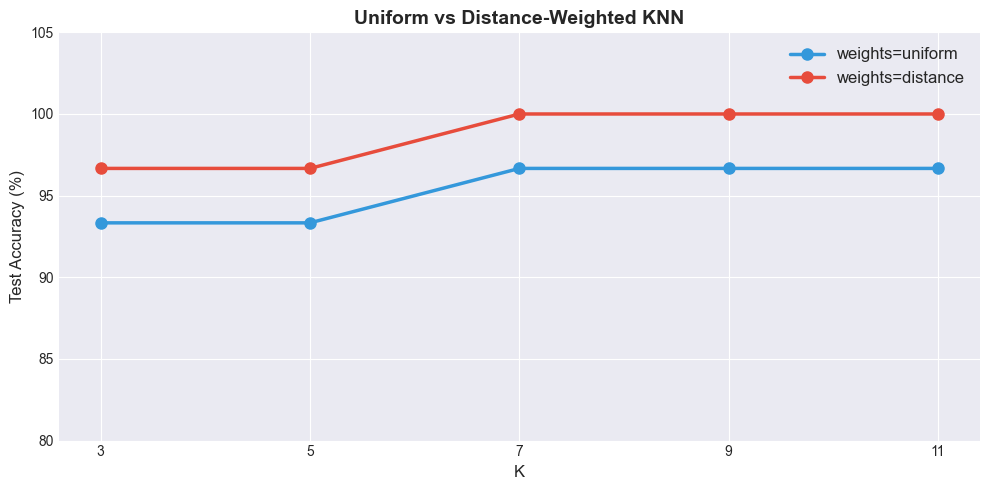

Weights  distance  uniform
K                         
3           96.67    93.33
5           96.67    93.33
7          100.00    96.67
9          100.00    96.67
11         100.00    96.67


In [19]:
# ============================================================
# ⚖️ Uniform vs Distance-Weighted KNN Comparison
# ============================================================

results = []
for k in [3, 5, 7, 9, 11]:
    for weights in ['uniform', 'distance']:
        knn = KNeighborsClassifier(n_neighbors=k, weights=weights)
        knn.fit(X_tr_iris, y_tr_iris)
        acc = knn.score(X_te_iris, y_te_iris)
        results.append({'K': k, 'Weights': weights, 'Accuracy': acc * 100})

results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
for weights, color in zip(['uniform', 'distance'], ['#3498DB', '#E74C3C']):
    subset = results_df[results_df['Weights'] == weights]
    ax.plot(subset['K'], subset['Accuracy'], 'o-', color=color,
            label=f'weights={weights}', linewidth=2.5, markersize=8)

ax.set_title('Uniform vs Distance-Weighted KNN', fontsize=14, fontweight='bold')
ax.set_xlabel('K', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.legend(fontsize=12)
ax.set_xticks([3, 5, 7, 9, 11])
ax.set_ylim([80, 105])
plt.tight_layout()
plt.show()

print(results_df.pivot(index='K', columns='Weights', values='Accuracy').round(2))

---
## 🔟 Pros & Cons of KNN

### ✅ Advantages:
| Advantage | Explanation |
|---|---|
| Simple & Intuitive | Easy to understand and explain |
| No Training Phase | Works immediately — lazy learner |
| Non-Parametric | No assumptions about data distribution |
| Naturally handles multi-class | No modification needed |
| Adapts to new training data | Since it memorizes all data |

### ❌ Disadvantages:
| Disadvantage | Explanation |
|---|---|
| Slow at prediction time | Computes distance to ALL training points |
| High memory usage | Stores entire dataset |
| Sensitive to irrelevant features | All features contribute equally to distance |
| Sensitive to feature scale | MUST apply feature scaling |
| Curse of Dimensionality | Performance degrades with high dimensions |
| Choosing K is tricky | Needs cross-validation |


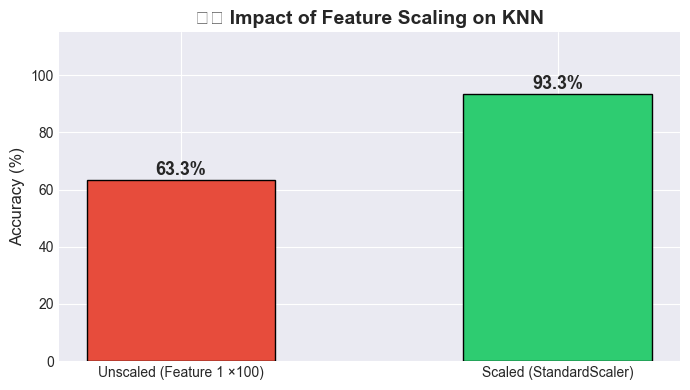

Unscaled Accuracy : 63.33%
Scaled Accuracy   : 93.33%

💡 Always scale your features before applying KNN!


In [20]:
# ============================================================
# ⚠️ Why Feature Scaling Matters for KNN
# ============================================================

# Create unscaled vs scaled comparison
X_tr_unscaled, X_te_unscaled = X_tr_iris * np.array([100, 1, 1, 1]), X_te_iris * np.array([100, 1, 1, 1])

knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_tr_unscaled, y_tr_iris)
acc_unscaled = knn_unscaled.score(X_te_unscaled, y_te_iris)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_tr_iris, y_tr_iris)  # Already scaled
acc_scaled = knn_scaled.score(X_te_iris, y_te_iris)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Unscaled (Feature 1 ×100)', 'Scaled (StandardScaler)'],
               [acc_unscaled * 100, acc_scaled * 100],
               color=['#E74C3C', '#2ECC71'], edgecolor='black', width=0.5)
for bar, val in zip(bars, [acc_unscaled * 100, acc_scaled * 100]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_title('⚠️ Impact of Feature Scaling on KNN', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 115)
plt.tight_layout()
plt.show()
print(f"Unscaled Accuracy : {acc_unscaled*100:.2f}%")
print(f"Scaled Accuracy   : {acc_scaled*100:.2f}%")
print("\n💡 Always scale your features before applying KNN!")

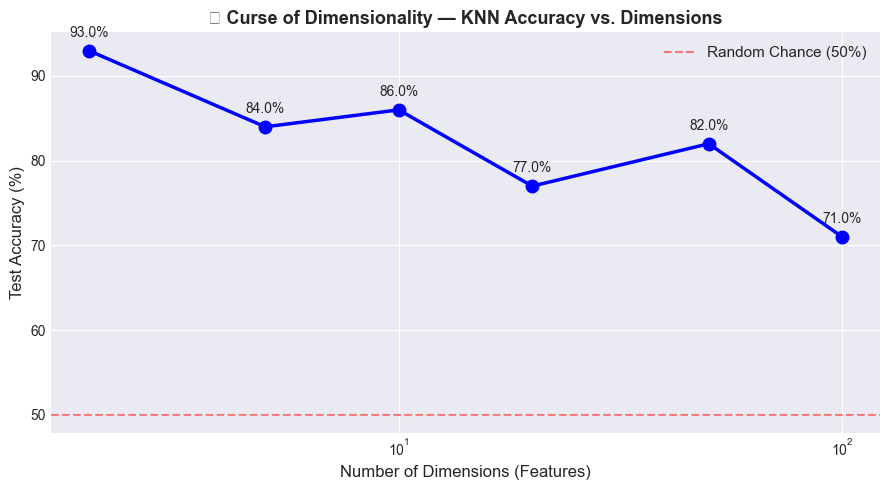

💡 KNN performance degrades as dimensionality increases.
   Apply PCA or feature selection before using KNN on high-dimensional data.


In [21]:
# ============================================================
# 🌀 Curse of Dimensionality Demo
# ============================================================

from sklearn.datasets import make_classification

dimensions = [2, 5, 10, 20, 50, 100]
accuracies = []

for n_features in dimensions:
    X_d, y_d = make_classification(
        n_samples=500, n_features=n_features,
        n_informative=max(2, n_features//3),
        n_redundant=0, random_state=42
    )
    X_d = StandardScaler().fit_transform(X_d)
    X_tr_dim, X_te_dim, y_tr_dim, y_te_dim = train_test_split(X_d, y_d, test_size=0.2, random_state=42)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_tr_dim, y_tr_dim)
    accuracies.append(knn.score(X_te_dim, y_te_dim) * 100)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(dimensions, accuracies, 'bo-', linewidth=2.5, markersize=9)
for x, y in zip(dimensions, accuracies):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=10)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Random Chance (50%)')
ax.set_title('🌀 Curse of Dimensionality — KNN Accuracy vs. Dimensions', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Dimensions (Features)', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_xscale('log')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()
print("💡 KNN performance degrades as dimensionality increases.")
print("   Apply PCA or feature selection before using KNN on high-dimensional data.")

---
## 📋 Summary — Key Takeaways

| Concept | Key Point |
|---|---|
| **Algorithm** | Find K nearest neighbours → vote (class) or average (regression) |
| **Lazy Learner** | No training — predicts at query time |
| **Hyperparameter K** | Low K = overfitting, High K = underfitting |
| **Distance Metrics** | Euclidean (default), Manhattan, Minkowski |
| **Feature Scaling** | **Mandatory** — use StandardScaler or MinMaxScaler |
| **Weighted KNN** | `weights='distance'` often improves performance |
| **Curse of Dimensionality** | KNN struggles in high-dimensional spaces |
| **Time Complexity** | O(n × d) per prediction — slow on large datasets |

---